# Topic 4. Neural Networks for Multiclass Classification and Regression

## Multiclass Classification with PyTorch: Palmer Penguins

### 1. Imports

In [1]:
# Import libraries for data processing, visualization,
# preprocessing, model training, and evaluation

from dataclasses import dataclass

import pandas as pd
import numpy as np

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import TargetEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


import matplotlib.pyplot as plt
import seaborn as sns

import warnings

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

### 2. Load the Dataset

In [2]:
# Load the Palmer Penguins dataset
df = pd.read_csv('../data/Module_2_Lecture_2_Class_penguins.csv')

# Display a reproducible random sample
df.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Gentoo,Biscoe,45.3,13.7,210.0,4300.0,female
157,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,female
225,Gentoo,Biscoe,46.5,14.8,217.0,5200.0,female
208,Gentoo,Biscoe,43.8,13.9,208.0,4300.0,female
318,Chinstrap,Dream,50.9,19.1,196.0,3550.0,male


### 3. Exploratory Data Analysis

In [3]:
# Inspect dataset structure, data types, and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


In [4]:
# Remove rows containing missing values and reset the index
df = df.dropna().reset_index(drop=True)

# Verify that no missing values remain
df.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

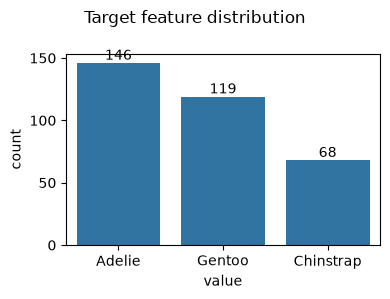

In [5]:
# Visualize the distribution of the target classes
plt.figure(figsize=(4,3))

ax = sns.countplot(data=df, x='species')

for i in ax.containers:
    ax.bar_label(i)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.suptitle("Target feature distribution")
plt.tight_layout()
plt.show()

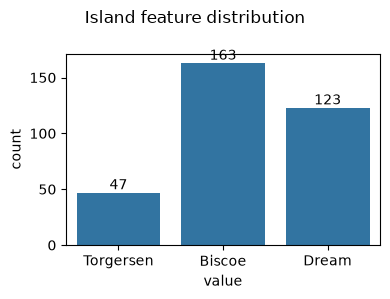

In [6]:
# Visualize the distribution of the Island feature
plt.figure(figsize=(4,3))

ax = sns.countplot(data=df, x='island')

for i in ax.containers:
    ax.bar_label(i)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

plt.suptitle("Island feature distribution")
plt.tight_layout()
plt.show()

<Figure size 600x600 with 0 Axes>

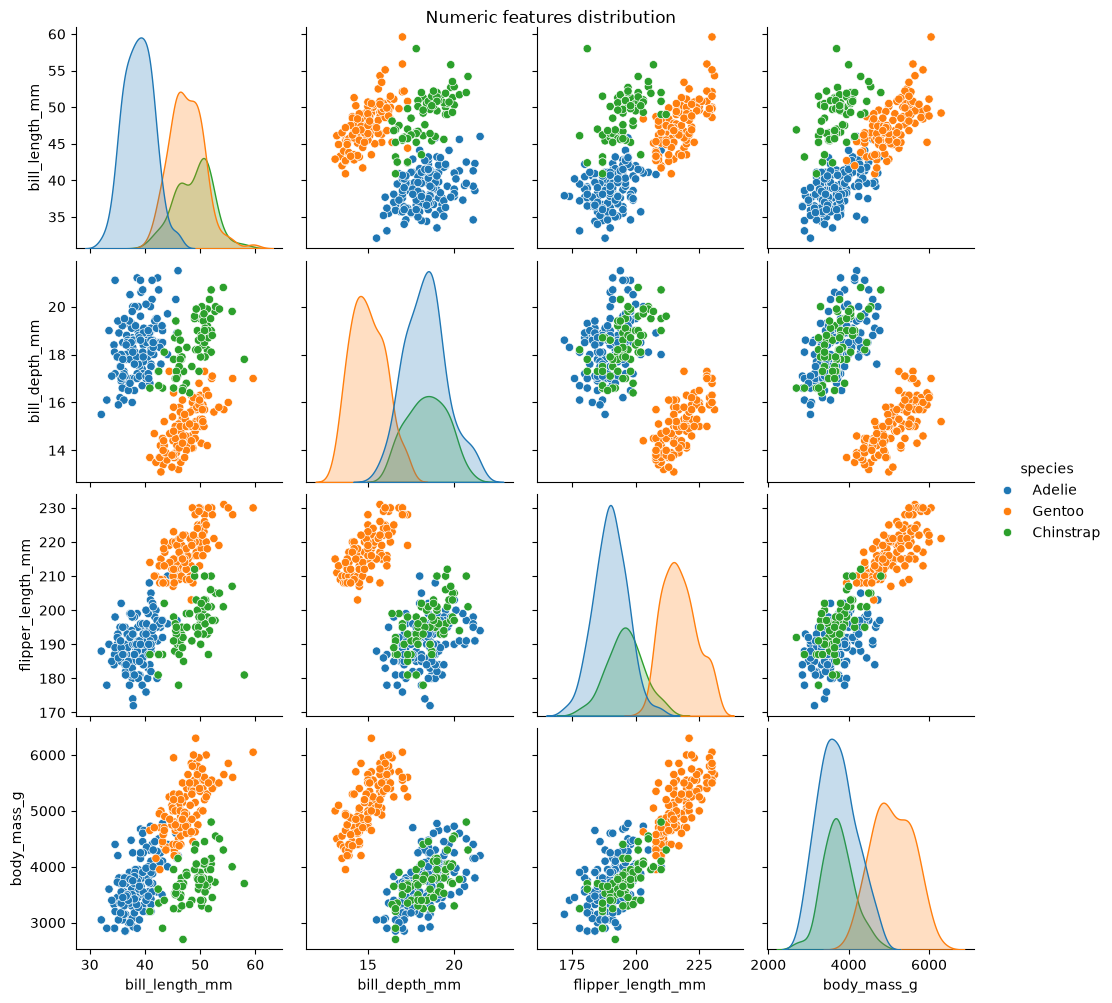

In [7]:
# Visualize pairwise relationships between numerical features
# and inspect how well the penguin species form separate clusters
plt.figure(figsize=(6,6))

sns.pairplot(data=df, hue='species').fig.suptitle(
    'Numeric features distribution',
    y=1
)

plt.show()

## Feature Preparation

In [8]:
# Define target and input features
TARGET = 'species'

NUMERICAL_FEATURES = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

CATEGORICAL_FEATURES = [
    'island',
    'sex'
]

FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES


# Encode the target classes as integer labels
df[TARGET] = df[TARGET].map({
    'Adelie': 0,
    'Gentoo': 1,
    'Chinstrap': 2
})


# Separate input features from the target variable
X = df[FEATURES]
y = df[TARGET].values


# Split the data before fitting preprocessing transformations
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    random_state=42,
    test_size=0.33,
    stratify=y
)

In [9]:
# Apply scaling to numerical features and One-Hot Encoding
# to categorical features
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            NUMERICAL_FEATURES
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore',
                sparse_output=False
            ),
            CATEGORICAL_FEATURES
        )
    ]
)


# Fit preprocessing only on the training data
X_train = preprocessor.fit_transform(X_train)

# Apply the learned transformations to the test data
X_test = preprocessor.transform(X_test)

In [10]:
# Convert NumPy arrays to PyTorch tensors
X_train = torch.Tensor(X_train).float()
y_train = torch.Tensor(y_train).long()

X_test = torch.Tensor(X_test).float()
y_test = torch.Tensor(y_test).long()

In [11]:
# Inspect one training example and the first ten class labels
print(X_train[:1])
print(y_train[:10])

tensor([[ 1.2903,  1.0033, -0.3723, -0.8205,  0.0000,  1.0000,  0.0000,  0.0000,
          1.0000]])
tensor([2, 0, 1, 1, 1, 2, 0, 1, 1, 0])


## Multiclass Classification: Model Preparation

In [12]:
# Define a small feed-forward neural network for multiclass classification
class LinearModel(torch.nn.Module):

    def __init__(self, in_dim, hidden_dim=20, out_dim=3):

        super().__init__()

        self.features = torch.nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim)
        )

    def forward(self, x):
        output = self.features(x)
        return output

In [13]:
# Initialize the model using the number of input features,
# 20 hidden neurons, and 3 output classes
model = LinearModel(X_train.shape[1], 20, 3)

model

LinearModel(
  (features): Sequential(
    (0): Linear(in_features=9, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=3, bias=True)
  )
)

In [14]:
# CrossEntropyLoss combines multiclass classification loss
# with the appropriate log-softmax transformation internally
criterion = nn.CrossEntropyLoss()

# Use stochastic gradient descent to update model parameters
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

## Training and Validation

In [15]:
# Train the model and track training and validation metrics
num_epoch = 400

train_loss = []
test_loss = []

train_accs = []
test_accs = []

for epoch in range(num_epoch):

    # ---- Training ----
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    predictions = torch.argmax(outputs, dim=1)
    acc = 100 * (predictions == y_train).sum().item() / len(y_train)

    train_loss.append(loss.item())
    train_accs.append(acc)

    # ---- Validation ----
    model.eval()

    with torch.no_grad():

        outputs = model(X_test)
        loss = criterion(outputs, y_test)

        predictions = torch.argmax(outputs, dim=1)
        acc = 100 * (predictions == y_test).sum().item() / len(y_test)

        test_loss.append(loss.item())
        test_accs.append(acc)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(
            f'Epoch [{epoch + 1}/{num_epoch}] '
            f'Train Loss: {train_loss[-1]:.4f} '
            f'Train Acc: {train_accs[-1]:.2f}% '
            f'Validation Acc: {test_accs[-1]:.2f}%'
        )

Epoch [10/400] Train Loss: 1.0217 Train Acc: 52.91% Validation Acc: 59.09%
Epoch [20/400] Train Loss: 0.9966 Train Acc: 58.30% Validation Acc: 60.91%
Epoch [30/400] Train Loss: 0.9721 Train Acc: 63.23% Validation Acc: 61.82%
Epoch [40/400] Train Loss: 0.9480 Train Acc: 69.96% Validation Acc: 65.45%
Epoch [50/400] Train Loss: 0.9242 Train Acc: 70.85% Validation Acc: 69.09%
Epoch [60/400] Train Loss: 0.9005 Train Acc: 73.99% Validation Acc: 75.45%
Epoch [70/400] Train Loss: 0.8767 Train Acc: 76.68% Validation Acc: 77.27%
Epoch [80/400] Train Loss: 0.8529 Train Acc: 78.48% Validation Acc: 79.09%
Epoch [90/400] Train Loss: 0.8290 Train Acc: 79.37% Validation Acc: 80.00%
Epoch [100/400] Train Loss: 0.8050 Train Acc: 79.37% Validation Acc: 80.91%
Epoch [110/400] Train Loss: 0.7809 Train Acc: 80.27% Validation Acc: 82.73%
Epoch [120/400] Train Loss: 0.7569 Train Acc: 82.96% Validation Acc: 83.64%
Epoch [130/400] Train Loss: 0.7328 Train Acc: 84.30% Validation Acc: 83.64%
Epoch [140/400] Train

## Training Results

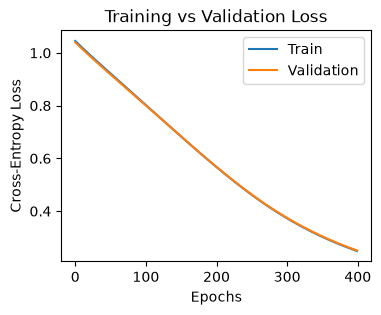

In [16]:
# Plot training and validation loss across epochs
plt.figure(figsize=(4, 3))

plt.plot(train_loss, label='Train')
plt.plot(test_loss, label='Validation')

plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training vs Validation Loss')

plt.show()

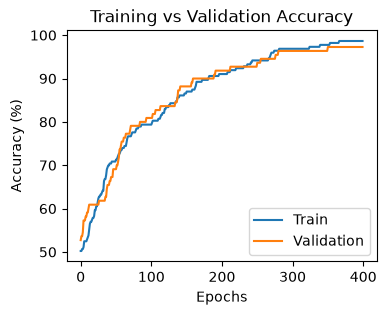

In [17]:
# Plot training and validation accuracy across epochs
plt.figure(figsize=(4, 3))

plt.plot(train_accs, label='Train')
plt.plot(test_accs, label='Validation')

plt.legend(loc='best')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.title('Training vs Validation Accuracy')

plt.show()

## Conclusion

The neural network successfully learned to classify three Palmer Penguin
species using both numerical physical measurements and categorical features
such as island and sex.

The final model achieved approximately:

- **98.65% training accuracy**
- **97.27% validation accuracy**

Training and validation performance remained close throughout training,
suggesting that the model generalizes well without substantial overfitting.

The experiment demonstrates how a small feed-forward neural network with a
ReLU hidden layer and Cross-Entropy Loss can effectively solve a multiclass
classification problem using a combination of standardized numerical features
and one-hot encoded categorical features.